<a href="https://colab.research.google.com/github/Licuao/TelecomX/blob/main/Telecomx2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests

In [ ]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response = requests.get(url)
response.status_code

200

In [ ]:
data = response.json()
type(data)

list

In [ ]:
df = pd.json_normalize(data)

In [ ]:
df.shape[0]

7267

In [ ]:
df = df.drop(columns=['customerID'])
display(df.head())

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
display(df_encoded.head())
print(f"Shape of the original DataFrame: {df.shape}")
print(f"Shape of the encoded DataFrame: {df_encoded.shape}")

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,Churn_No,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,account.Charges.Total_995.35,account.Charges.Total_996.45,account.Charges.Total_996.85,account.Charges.Total_996.95,account.Charges.Total_997.65,account.Charges.Total_997.75,account.Charges.Total_998.1,account.Charges.Total_999.45,account.Charges.Total_999.8,account.Charges.Total_999.9
0,0,9,65.6,True,False,False,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,False,True,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,False,True,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


Shape of the original DataFrame: (7267, 20)
Shape of the encoded DataFrame: (7267, 6561)


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_proportions = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:")
display(churn_counts)
print("\nChurn Proportions (%):")
display(churn_proportions)

if churn_proportions['Yes'] < 30:
    print("\nThere appears to be a class imbalance, as the proportion of churned customers is relatively low.")
else:
    print("\nClass balance appears to be reasonable.")

Churn Counts:


,count
Churn,
No,5174
Yes,1869
,224



Churn Proportions (%):


,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427



There appears to be a class imbalance, as the proportion of churned customers is relatively low.


/tmp/ipykernel_1058/2372507189.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_proportions.index, y=churn_proportions.values, palette='viridis')


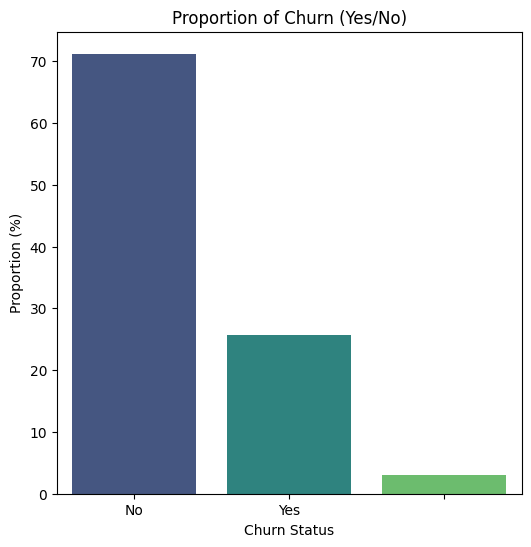

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.barplot(x=churn_proportions.index, y=churn_proportions.values, palette='viridis')
plt.title('Proportion of Churn (Yes/No)')
plt.xlabel('Churn Status')
plt.ylabel('Proportion (%)')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Churn_No', 'Churn_Yes'])
y = df_encoded['Churn_Yes'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Original training set shape (X_train): {X_train.shape}")
print(f"Original training set target distribution (y_train):\n{y_train.value_counts(normalize=True)}\n")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Resampled training set shape (X_train_res): {X_train_res.shape}")
print(f"Resampled training set target distribution (y_train_res):\n{y_train_res.value_counts(normalize=True)}")

Original training set shape (X_train): (5086, 6559)
Original training set target distribution (y_train):
Churn_Yes
0    0.742823
1    0.257177
Name: proportion, dtype: float64

Resampled training set shape (X_train_res): (7556, 6559)
Resampled training set target distribution (y_train_res):
Churn_Yes
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df_encoded.select_dtypes(include=['number', 'bool']).columns.tolist()

df_numerical = df_encoded[numerical_cols]
if 'Churn_No' in df_numerical.columns:
    df_numerical = df_numerical.drop(columns=['Churn_No'])

correlation_matrix = df_numerical.corr()

plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Matrix of Numerical Features and Churn')
plt.show()

churn_correlations = correlation_matrix['Churn_Yes'].sort_values(ascending=False)
print("\nCorrelations with Churn_Yes:")
display(churn_correlations)

### Feature Scaling (Normalization/Standardization)

Feature scaling is a preprocessing step that transforms numerical features to a standard range or distribution. This is important for many machine learning algorithms because:

*   **Distance-based algorithms (e.g., K-Nearest Neighbors, Support Vector Machines, Logistic Regression, Neural Networks):** These algorithms are sensitive to the magnitude and scale of features. If features have different scales, features with larger values might dominate the distance calculations, leading to biased models. Scaling ensures all features contribute equally.
*   **Gradient Descent based algorithms:** Algorithms that use gradient descent (like Logistic Regression and Neural Networks) converge much faster when features are scaled, as it prevents oscillations due to features with different scales.

There are two common types of scaling:
*   **Normalization (Min-Max Scaling):** Scales features to a fixed range, usually 0 to 1. (e.g., `(X - X_min) / (X_max - X_min)`)
*   **Standardization (Z-score Normalization):** Scales features to have a mean of 0 and a standard deviation of 1. (e.g., `(X - mean) / standard_deviation`)

For most cases, standardization (`StandardScaler`) is preferred as it handles outliers better than normalization and is robust to different data distributions.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_res.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Shape of scaled training data:", X_train_scaled.shape)
print("Shape of scaled test data:", X_test_scaled.shape)
display(X_train_scaled.head())

Shape of scaled training data: (7556, 6559)
Shape of scaled test data: (2181, 6559)


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,phone.MultipleLines_Yes,internet.InternetService_Fiber optic,...,account.Charges.Total_995.35,account.Charges.Total_996.45,account.Charges.Total_996.85,account.Charges.Total_996.95,account.Charges.Total_997.65,account.Charges.Total_997.75,account.Charges.Total_998.1,account.Charges.Total_999.45,account.Charges.Total_999.8,account.Charges.Total_999.9
0,-0.410137,1.843563,1.385001,-1.148571,1.023570,1.596063,0.313712,-0.334166,1.072785,0.958510,...,0.0,-0.011505,-0.011505,-0.011505,-0.032556,-0.011505,-0.011505,0.0,-0.011505,0.0
1,-0.410137,-0.936480,-1.651969,-1.148571,-0.976972,-0.626542,0.313712,-0.334166,-0.932153,-1.043286,...,0.0,-0.011505,-0.011505,-0.011505,-0.032556,-0.011505,-0.011505,0.0,-0.011505,0.0
2,2.438207,1.553111,1.343399,-1.148571,1.023570,-0.626542,0.313712,-0.334166,1.072785,0.958510,...,0.0,-0.011505,-0.011505,-0.011505,-0.032556,-0.011505,-0.011505,0.0,-0.011505,0.0
3,-0.410137,0.100850,0.409080,-1.148571,-0.976972,-0.626542,0.313712,-0.334166,1.072785,-1.043286,...,0.0,-0.011505,-0.011505,-0.011505,-0.032556,-0.011505,-0.011505,0.0,-0.011505,0.0
4,-0.410137,-0.563041,0.811236,-1.148571,1.023570,1.596063,0.313712,-0.334166,1.072785,0.958510,...,0.0,-0.011505,-0.011505,-0.011505,-0.032556,-0.011505,-0.011505,0.0,-0.011505,0.0


In [ ]:
import numpy as np

df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

print("Data type of 'account.Charges.Total' after conversion:", df['account.Charges.Total'].dtype)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='account.Contract', hue='Churn', palette='viridis')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='account.Charges.Total', palette='plasma')
plt.title('Total Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Total Charges')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_res)

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))